<a href="https://colab.research.google.com/github/j019/Practical-Machine-Learning/blob/main/Day11/Detect_dry_oily_skin_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Detect Dry , Oily & normal Skin

- Data : https://www.kaggle.com/datasets/ritikasinghkatoch/normaldryoily-skin-type/data

- unzip the data

In [1]:
! unzip /content/Detect_dry_oily_skin_CNN.zip

Archive:  /content/Detect_dry_oily_skin_CNN.zip
  inflating: data/dry/dry01.jpg      
  inflating: data/dry/dry02.jpg      
  inflating: data/dry/dry03.png      
  inflating: data/dry/dry04.jpg      
  inflating: data/dry/dry05.jpg      
  inflating: data/dry/dry06.png      
  inflating: data/dry/dry07.jpg      
  inflating: data/dry/dry08.jpg      
  inflating: data/dry/dry09.jpeg     
  inflating: data/dry/dry10.jpg      
  inflating: data/dry/dry11.jpeg     
  inflating: data/dry/dry12.jpeg     
  inflating: data/dry/dry13.jpeg     
  inflating: data/dry/dry15.jpeg     
  inflating: data/dry/dry16.jpeg     
  inflating: data/dry/dry17.jpeg     
  inflating: data/dry/dry18.jpeg     
  inflating: data/dry/dry19.jpeg     
  inflating: data/dry/dry20.jpeg     
  inflating: data/dry/dry21.jpeg     
  inflating: data/dry/dry22.jpeg     
  inflating: data/dry/dry23.jpeg     
  inflating: data/dry/dry24.jpeg     
  inflating: data/dry/dry25.jpeg     
  inflating: data/dry/dry26.jpeg     
  

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
import cv2
import numpy as np
import os
import pandas as pd

## Load Data By Generator

- ImageDataGenerator in Keras

In [3]:
# example of progressively loading images from file
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# create generator
# generator applied random preprocessing to make the model --> robust
datagen = ImageDataGenerator(rescale = 1./255,
                             shear_range = 0.2, # every image will be randomly distorted 0-0.2
                             zoom_range = 0.2, # every image will be randomly zoomed 0-0.2
                             horizontal_flip = True, #
                             vertical_flip=True,
                             rotation_range=30,
                             validation_split=0.3) #every image will be randomly ratated 0-30 degree
# prepare an iterators for each dataset
train_it = datagen.flow_from_directory( '/content/data',
                                       class_mode='categorical',
                                       classes=['dry', 'normal','oily'],
                                       subset='training',
                                       target_size=(224, 224), #Peform reshape Operation
                                       batch_size=2,
                                       seed=7)
val_it = datagen.flow_from_directory('/content/data',
                                       class_mode='categorical',
                                       classes=['dry', 'normal','oily'],
                                       target_size=(224, 224),
                                       subset='validation',
                                       batch_size=2,
                                       seed=7)
test_it = datagen.flow_from_directory('/content/data',
                                       class_mode='categorical',
                                       classes=['dry', 'normal','oily'],
                                       target_size=(224, 224),
                                       subset='validation',
                                       batch_size=2,
                                       seed=7)
# confirm the iterator works
batchX, batchy = next(train_it)
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape, batchX.min(), batchX.max()))

Found 80 images belonging to 3 classes.
Found 32 images belonging to 3 classes.
Found 32 images belonging to 3 classes.
Batch shape=(2, 224, 224, 3), min=0.000, max=0.999


# Create Simple CNN model

In [4]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Input
from tensorflow.keras import Sequential

In [5]:
model = Sequential()
model.add(Input((224,224,3))) # 3 --> No of channels
model.add(Conv2D(32, (5,5),padding='valid',activation='relu')) # 32--> No of kernels
model.add(MaxPooling2D(pool_size=(4,4)))
# REPEAT CONV AND POOLING layer 3 TIMES
model.add(Conv2D(64, (5,5),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(4,4)))
model.add(Conv2D(128, (5,5),padding='valid',activation='relu'))
# model.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
# model.add(MaxPooling2D(pool_size=(4,4)))
model.add(Flatten())
# any no of dense layers
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(3,activation='softmax')) # 3 --> classes that'why 3 ouptut

### Number of Params in Conv. Layer
- Weights ->  [Number of Kernels] x [No of Input channels] x [kernel length] x [kernel height]
- Bias -> Number of Kernels
- Ex : 32 kernels of Size 5x5, with 3 input channel
- 32x3x5x5+32 = 2432

In [6]:
32*3*5*5+32

2432

In [7]:
64*5*5*32+64

51264

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 51, 51, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,779 (5.02 MB)

 Trainable params: 1,315,779 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from keras.losses import BinaryCrossentropy
model.compile(
  optimizer='adam',
  loss=BinaryCrossentropy(),
  metrics=['accuracy'])

In [10]:
history = model.fit(
  train_it,
  validation_data=val_it,
  epochs=5)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.3375 - loss: 0.6912 - val_accuracy: 0.3438 - val_loss: 0.6511
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.3250 - loss: 0.6669 - val_accuracy: 0.3438 - val_loss: 0.6436
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.3000 - loss: 0.6551 - val_accuracy: 0.3125 - val_loss: 0.6443
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.3125 - loss: 0.6435 - val_accuracy: 0.3438 - val_loss: 0.6365
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.2500 - loss: 0.6407 - val_accuracy: 0.3438 - val_loss: 0.6357


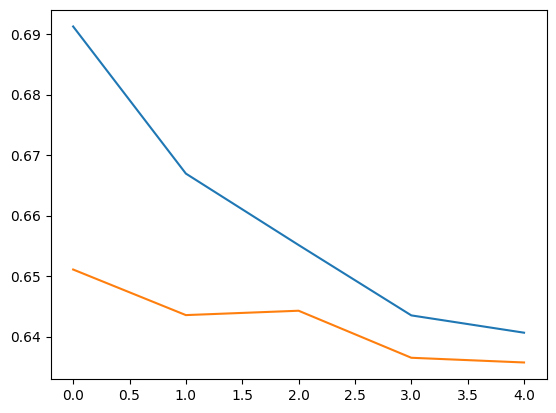

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

# VGG16 Model (Transfer Learning)

#### add preprocessing layer to the front of VGG
#### [3] add 3 Channles ie RGB
#### We are importing weights from imagenet use it as it is
#### include_top means we last layer in VGG16 Model we dont want this
#### Because with help of VGG we are tyring to solve own problem

## Transfer Learning

In [14]:
IMAGE_SIZE = [224, 224, 3]

In [16]:
# Not Including Dense layer / Fully Connected Layer
# imagenet --> Dataset --> for 1000 model Classification
vgg = VGG16(input_shape=IMAGE_SIZE, weights='imagenet', include_top=False)

- Don't Train existing Weights

In [17]:
for layer in vgg.layers:
  layer.trainable = False

# Add Our Layers at End of VGG16

In [19]:
#Functional Modal

output_classes = 3
# our layers - you can add more if you want
x = Flatten()(vgg.output)
x = Dense(10, activation='relu')(x)
# x = Dense(500, activation='relu')(x)
prediction = Dense(output_classes, activation='softmax')(x)

In [20]:
# create a model object
model = Model(inputs=vgg.input, outputs=prediction)

In [21]:
# view the structure of the model
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │       250,890 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,965,611 (57.09 MB)

 Trainable params: 250,923 (980.17 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [22]:
# tell the model what cost and optimization method to use
model.compile(
  loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [26]:
history_vgg= model.fit(
  train_it,
  validation_data=val_it,
  epochs=50
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.4125 - loss: 0.6768 - val_accuracy: 0.3438 - val_loss: 0.6861
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3375 - loss: 0.6850 - val_accuracy: 0.3438 - val_loss: 0.6835
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.3375 - loss: 0.6825 - val_accuracy: 0.3438 - val_loss: 0.6810
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.3375 - loss: 0.6800 - val_accuracy: 0.3438 - val_loss: 0.6786
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.3375 - loss: 0.6777 - val_accuracy: 0.3438 - val_loss: 0.6764
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3375 - loss: 0.6755 - val_accuracy: 0.3438 - val_loss: 0.6743
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3375 - loss: 0.6735 - val_accuracy: 0.3438 - val_loss: 0.6723
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.3375 - loss: 0.6715 - val_accuracy: 0.3438 - v

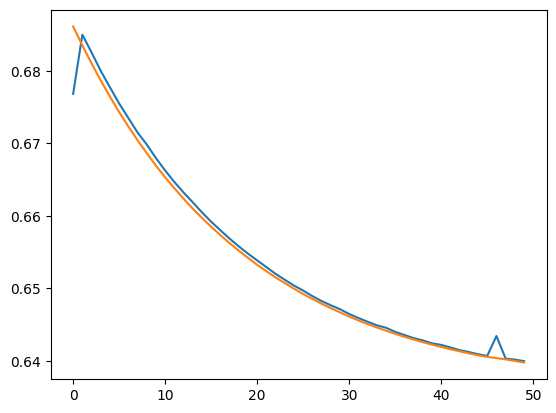

In [27]:
import matplotlib.pyplot as plt
plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])

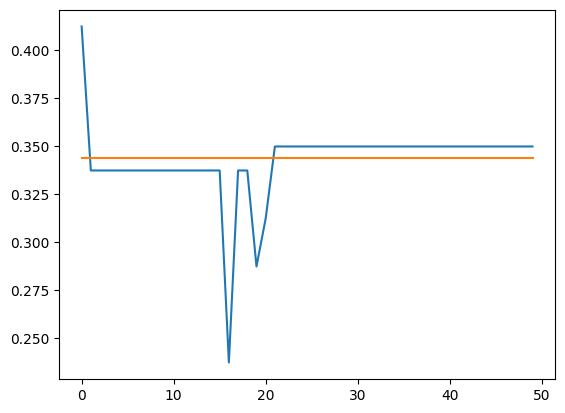

In [28]:
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])

# RESNET50 Model



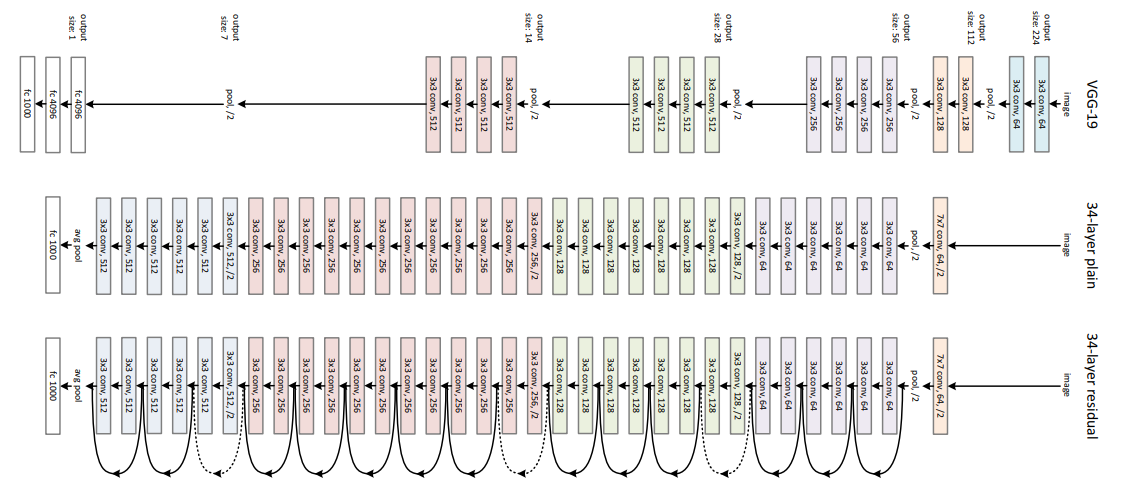

In [29]:
from tensorflow.keras.applications import ResNet50

In [30]:
resnet = ResNet50(include_top=True,weights="imagenet",input_shape=(224,224,3),classes=1000)

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [31]:
resnet.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

- Trained on 1000 classes --> That's why it giving 1000 neurons in output

In [32]:
for layer in resnet.layers[:-2]:
  layer.trainable = False

- Add Our Layers at End of Resnet50

In [33]:
output_classes = 3
# our layers - you can add more if you want
x = Dense(10, activation='relu')(resnet.layers[-2].output)
# x = Dense(5000, activation='relu')(x)
# x = Dense(500, activation='relu')(x)
prediction = Dense(output_classes, activation='softmax')(x)

In [34]:
# create a model object
model = Model(inputs=resnet.input, outputs=prediction)

In [35]:
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,608,235 (90.06 MB)

 Trainable params: 20,523 (80.17 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [36]:
model.compile(
  loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [37]:
history_resnet= model.fit(
  train_it,
  validation_data=val_it,
  epochs=5
  )

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 168ms/step - accuracy: 0.2625 - loss: 0.7105 - val_accuracy: 0.3438 - val_loss: 0.6903
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.3375 - loss: 0.6892 - val_accuracy: 0.3438 - val_loss: 0.6877
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.3375 - loss: 0.6866 - val_accuracy: 0.3438 - val_loss: 0.6852
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.3375 - loss: 0.6840 - val_accuracy: 0.3438 - val_loss: 0.6827
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.3375 - loss: 0.6816 - val_accuracy: 0.3438 - val_loss: 0.6803


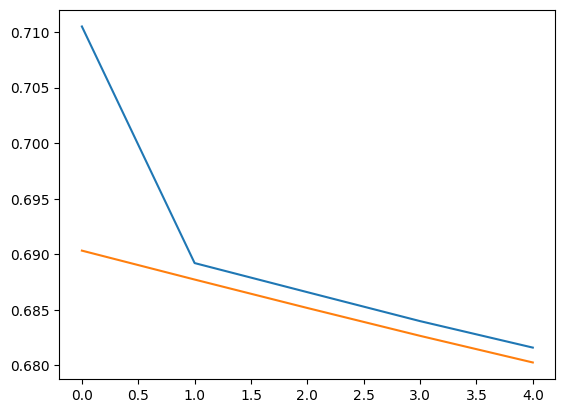

In [38]:
plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])

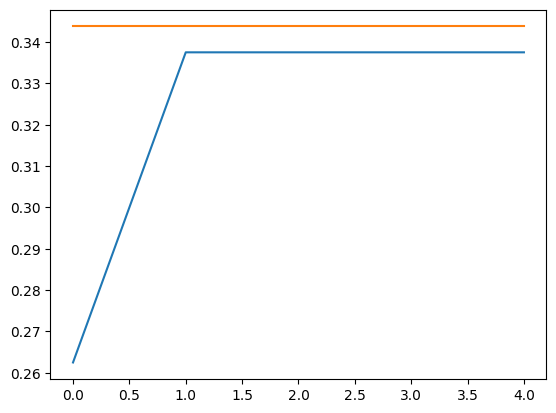

In [39]:
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])

1. Create CNN models
	conv kernel 3 by 3, padding valid, stride=1, pooling kernel 2 by 2
	 - 1 convolution + 1 pooling + flatten + 2 dense layers
	- 2 convolution + pooling + 2 convolution + pooling + flatten + 2 dense layers
	- 2 convolution + pooling + 2 convolution + pooling + flatten + 4 dense layers

In [53]:
model1 = Sequential()
model1.add(Input((224,224,3))) # 3 --> No of channels
model1.add(Conv2D(32, (5,5),padding='valid',strides=1,activation='relu')) # 32--> No of kernels
model1.add(MaxPooling2D(pool_size=(2,2)))
model1.add(Flatten())
model1.add(Dense(10,activation='relu'))
model1.add(Dense(12,activation='relu'))
model1.add(Dense(3,activation='softmax'))

In [54]:
model1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 220, 220, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 387200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │     3,872,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 12)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,874,613 (14.78 MB)

 Trainable params: 3,874,613 (14.78 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model1.compile(
  optimizer='adam',
  loss=BinaryCrossentropy(),
  metrics=['accuracy'])

In [56]:
history = model1.fit(
  train_it,
  validation_data=val_it,
  epochs=5)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.3125 - loss: 0.9842 - val_accuracy: 0.3750 - val_loss: 0.6766
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4000 - loss: 0.6689 - val_accuracy: 0.4062 - val_loss: 0.6711
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.3750 - loss: 0.6848 - val_accuracy: 0.3438 - val_loss: 0.6522
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.4625 - loss: 0.6638 - val_accuracy: 0.3125 - val_loss: 0.6354
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4750 - loss: 0.6587 - val_accuracy: 0.4375 - val_loss: 0.6262


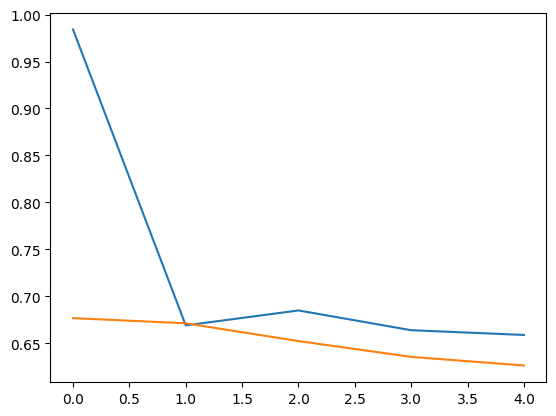

In [57]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [58]:
B = Sequential()
B.add(Input((224,224,3))) # 3 --> No of channels
B.add(Conv2D(32, (3,3),padding='valid',strides=1,activation='relu'))
B.add(Conv2D(20, (3,3),padding='valid',strides=1,activation='relu'))
B.add(MaxPooling2D(pool_size=(2,2)))

B.add(Conv2D(23, (3,3),padding='valid',strides=1,activation='relu'))
B.add(Conv2D(14, (3,3),padding='valid',strides=1,activation='relu'))
B.add(MaxPooling2D(pool_size=(2,2)))

B.add(Flatten())
B.add(Dense(10,activation='relu'))
B.add(Dense(8,activation='relu'))
B.add(Dense(3,activation='softmax'))

In [59]:
B.compile(
  optimizer='adam',
  loss=BinaryCrossentropy(),
  metrics=['accuracy'])

In [60]:
history = B.fit(
  train_it,
  validation_data=val_it,
  epochs=5)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.2875 - loss: 0.7035 - val_accuracy: 0.3125 - val_loss: 0.6899
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.2750 - loss: 0.6884 - val_accuracy: 0.3125 - val_loss: 0.6867
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2500 - loss: 0.6853 - val_accuracy: 0.3125 - val_loss: 0.6835
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.3125 - loss: 0.6820 - val_accuracy: 0.3125 - val_loss: 0.6803
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.3125 - loss: 0.6788 - val_accuracy: 0.3125 - val_loss: 0.6770


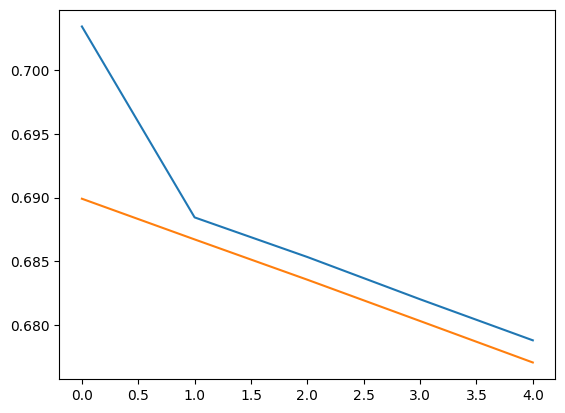

In [61]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [72]:
C = Sequential()
C.add(Input((224,224,3))) # 3 --> No of channels
C.add(Conv2D(32, (3,3),padding='valid',strides=1,activation='relu'))
C.add(Conv2D(20, (3,3),padding='valid',strides=1,activation='relu'))
C.add(MaxPooling2D(pool_size=(2,2)))

C.add(Conv2D(23, (3,3),padding='valid',strides=1,activation='relu'))
C.add(Conv2D(14, (3,3),padding='valid',strides=1,activation='relu'))
C.add(MaxPooling2D(pool_size=(2,2)))

C.add(Flatten())
C.add(Dense(24,activation='relu'))
C.add(Dense(18,activation='relu'))
C.add(Dense(10,activation='relu'))
C.add(Dense(8,activation='relu'))
C.add(Dense(3,activation='softmax'))

In [73]:
C.compile(
  optimizer='adam',
  loss=BinaryCrossentropy(),
  metrics=['accuracy'])

In [74]:
history = C.fit(
  train_it,
  validation_data=val_it,
  epochs=5)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.3125 - loss: 0.6973 - val_accuracy: 0.3438 - val_loss: 0.6864
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.2875 - loss: 0.6738 - val_accuracy: 0.3438 - val_loss: 0.6423
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.3625 - loss: 0.6505 - val_accuracy: 0.3125 - val_loss: 0.6380
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.3375 - loss: 0.6444 - val_accuracy: 0.3438 - val_loss: 0.6445
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.3375 - loss: 0.6486 - val_accuracy: 0.3125 - val_loss: 0.6382


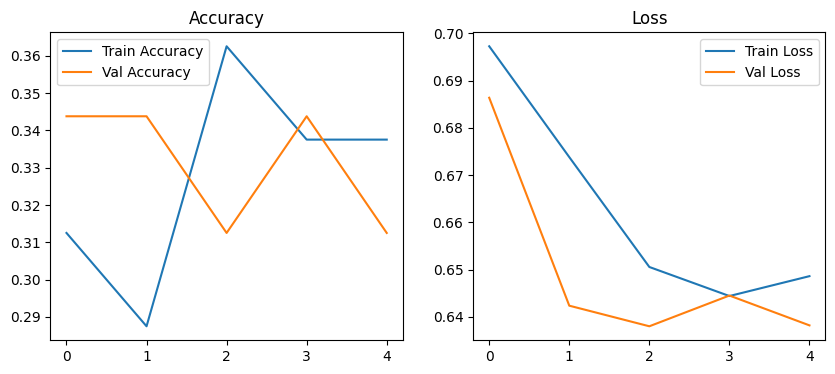

In [75]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [76]:
# C-a)
C = Sequential()
C.add(Input((224,224,3))) # 3 --> No of channels
C.add(Conv2D(32, (5,5),padding='valid',strides=1,activation='relu'))
C.add(Conv2D(20, (5,5),padding='valid',strides=1,activation='relu'))
C.add(MaxPooling2D(pool_size=(2,2)))

C.add(Conv2D(23, (5,5),padding='valid',strides=1,activation='relu'))
C.add(Conv2D(14, (5,5),padding='valid',strides=1,activation='relu'))
C.add(MaxPooling2D(pool_size=(2,2)))

C.add(Flatten())
C.add(Dense(24,activation='relu'))
C.add(Dense(18,activation='relu'))
C.add(Dense(10,activation='relu'))
C.add(Dense(8,activation='relu'))
C.add(Dense(3,activation='softmax'))

In [77]:
C.compile(
  optimizer='adam',
  loss=BinaryCrossentropy(),
  metrics=['accuracy'])

In [78]:
history = C.fit(
  train_it,
  validation_data=val_it,
  epochs=5)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.3500 - loss: 0.6799 - val_accuracy: 0.3438 - val_loss: 0.6737
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.3375 - loss: 0.7093 - val_accuracy: 0.3438 - val_loss: 0.6632
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3375 - loss: 0.6707 - val_accuracy: 0.3438 - val_loss: 0.6625
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.3125 - loss: 0.6640 - val_accuracy: 0.5000 - val_loss: 0.6688
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.3250 - loss: 0.7333 - val_accuracy: 0.3438 - val_loss: 0.6623


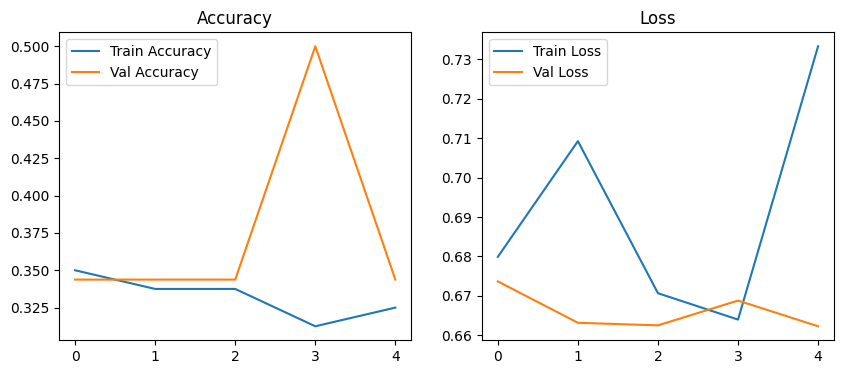

In [79]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [80]:
# C-b)
C = Sequential()
C.add(Input((224,224,3))) # 3 --> No of channels
C.add(Conv2D(32, (3,3),padding='valid',strides=2,activation='relu'))
C.add(Conv2D(20, (3,3),padding='valid',strides=2,activation='relu'))
C.add(MaxPooling2D(pool_size=(2,2)))

C.add(Conv2D(23, (3,3),padding='valid',strides=2,activation='relu'))
C.add(Conv2D(14, (3,3),padding='valid',strides=2,activation='relu'))
C.add(MaxPooling2D(pool_size=(2,2)))

C.add(Flatten())
C.add(Dense(24,activation='relu'))
C.add(Dense(18,activation='relu'))
C.add(Dense(10,activation='relu'))
C.add(Dense(8,activation='relu'))
C.add(Dense(3,activation='softmax'))

In [82]:
C.compile(
  optimizer='adam',
  loss=BinaryCrossentropy(),
  metrics=['accuracy'])

In [83]:
history = C.fit(
  train_it,
  validation_data=val_it,
  epochs=5)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.3125 - loss: 0.6704 - val_accuracy: 0.3125 - val_loss: 0.6476
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3250 - loss: 0.6486 - val_accuracy: 0.3438 - val_loss: 0.6430
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.3375 - loss: 0.6407 - val_accuracy: 0.3438 - val_loss: 0.6364
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.2875 - loss: 0.6388 - val_accuracy: 0.4062 - val_loss: 0.6363
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3125 - loss: 0.6379 - val_accuracy: 0.4375 - val_loss: 0.6359


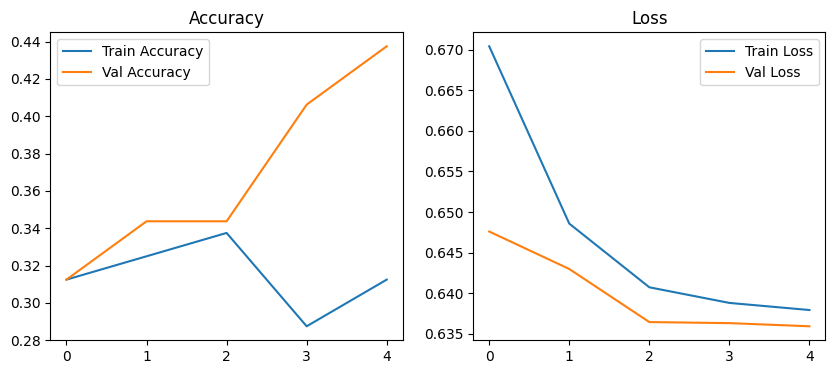

In [84]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [85]:
# C-c)
C = Sequential()
C.add(Input((224,224,3))) # 3 --> No of channels
C.add(Conv2D(32, (5,5),padding='same',strides=1,activation='relu'))
C.add(Conv2D(20, (5,5),padding='same',strides=1,activation='relu'))
C.add(MaxPooling2D(pool_size=(2,2)))

C.add(Conv2D(23, (5,5),padding='same',strides=1,activation='relu'))
C.add(Conv2D(14, (5,5),padding='same',strides=1,activation='relu'))
C.add(MaxPooling2D(pool_size=(2,2)))

C.add(Flatten())
C.add(Dense(24,activation='relu'))
C.add(Dense(18,activation='relu'))
C.add(Dense(10,activation='relu'))
C.add(Dense(8,activation='relu'))
C.add(Dense(3,activation='softmax'))

In [90]:
import keras
C.compile(
  optimizer='adam',
  loss=BinaryCrossentropy(),
  metrics=['accuracy', keras.metrics.F1Score(name='f1_score')])

In [91]:
history = C.fit(
  train_it,
  validation_data=val_it,
  epochs=5)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.3375 - f1_score: 0.1682 - loss: 0.6998 - val_accuracy: 0.3438 - val_f1_score: 0.1705 - val_loss: 0.6893
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.3375 - f1_score: 0.1682 - loss: 0.6828 - val_accuracy: 0.3438 - val_f1_score: 0.1705 - val_loss: 0.6594
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.3375 - f1_score: 0.1682 - loss: 0.6672 - val_accuracy: 0.3438 - val_f1_score: 0.1705 - val_loss: 0.6583
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3375 - f1_score: 0.1682 - loss: 0.6635 - val_accuracy: 0.3438 - val_f1_score: 0.1705 - val_loss: 0.6714
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.3375 - f1_score: 0.1682 - loss: 0.6460 - val_accuracy: 0.3438 - val_f1_score: 0.1705 - val_loss: 0.6442


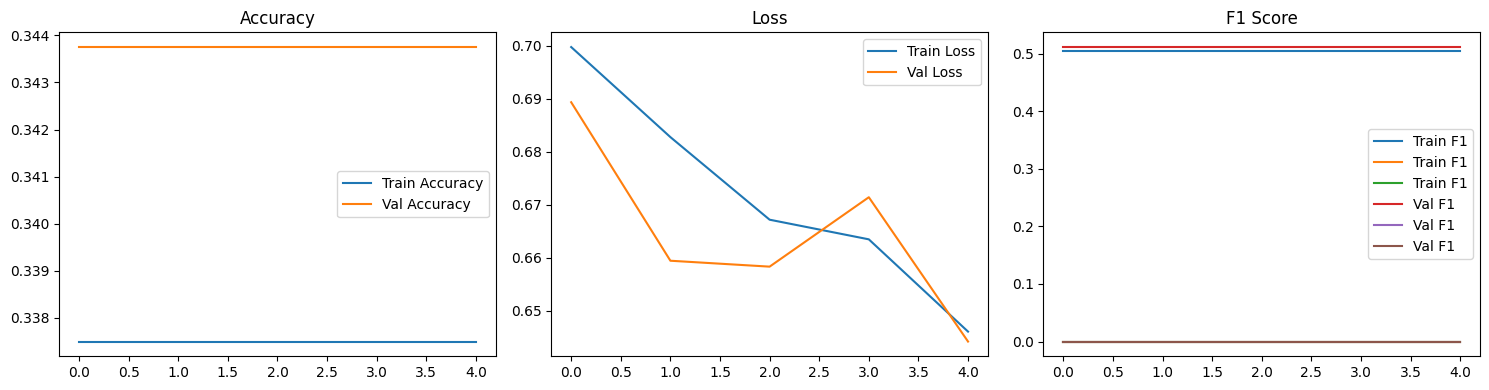

In [92]:
plt.figure(figsize=(15, 4)) # Widened to 15 to fit three plots nicely

# 1. Accuracy Plot
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

# 2. Loss Plot
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

# 3. F1 Score Plot
plt.subplot(1, 3, 3)
plt.plot(history.history['f1_score'], label='Train F1')
plt.plot(history.history['val_f1_score'], label='Val F1')
plt.legend()
plt.title('F1 Score')

plt.tight_layout() # Prevents subplots from overlapping
plt.show()